# Download the dataset and SAM files from drive

In [ ]:
# download dataset and unzip it to "data" folder
!wget "https://drive.iust.ac.ir/index.php/s/eJogJRaDJMqeyCb/download" -O data.zip
!unzip data.zip 

In [ ]:
# download sam-vit-base folder and unzip it to "sam-vit-base" folder
!wget "https://drive.iust.ac.ir/index.php/s/FyQimfTgjQRCr53/download" -O sam-vit-base.zip
!unzip sam-vit-base.zip 

In [ ]:
!pip install --index-url https://mirror2.chabokan.net/pypi/simple/ timm
!pip install --index-url https://mirror2.chabokan.net/pypi/simple/ peft

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
import torch.nn.functional as F

from PIL import Image
import os
import numpy as np
import timm
from tqdm import tqdm

import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Dataset

In [3]:
class PetsDataset(Dataset):
    def __init__(self,
                 split="trainval",
                 size=256):
        
        self.dataset = OxfordIIITPet(
            root="./data",
            split=split,
            target_types="segmentation",
            download=False
        )

        self.img_tf = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.mask_tf = transforms.Compose([
            transforms.Resize(
                (size, size),
                interpolation=Image.NEAREST
            )
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, trimap = self.dataset[idx]
        image = self.img_tf(image)
        trimap = np.array(self.mask_tf(trimap))
        mask = (trimap == 1).astype(np.float32)
        mask = torch.tensor(mask).unsqueeze(0)

        return image, mask


In [4]:
full_dataset = PetsDataset(split="trainval")

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

test_dataset = PetsDataset(split="test")

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False
)

## UNet Implementation

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)

## TransUNet Implementation

In [6]:
class UpSampler(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        
        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = nn.Sequential(
            nn.Conv2d(out_channels + skip_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

        
class TransUNet(nn.Module):
    def __init__(self, img_size=256, embed_dim=768):
        
        super().__init__()

        # encoder
        self.encoder = timm.create_model(
            "resnet50",
            pretrained=False,
            features_only=True,
            out_indices=(0,1,2,3,4)
        )
        
        state_dict = torch.load(
            "resnet50.pth",
            map_location="cpu"
        )
        self.encoder.load_state_dict(
            state_dict,
            strict=False
        )
        # transformer
        self.proj = nn.Conv2d(
            2048,
            embed_dim,
            kernel_size=1
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=8,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        
        # decoder
        self.decoder4 = UpSampler(embed_dim, 1024, 512)
        self.decoder3 = UpSampler(512, 512, 256)
        self.decoder2 = UpSampler(256, 256, 128)
        self.decoder1 = UpSampler(128, 64, 64)

        self.seg_head = nn.Conv2d(64,1,kernel_size=1)

    def forward(self, x):

        features = self.encoder(x)
        f1, f2, f3, f4, f5 = features
        x = self.proj(f5)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.transformer(x)
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.decoder4(x, f4)
        x = self.decoder3(x, f3)
        x = self.decoder2(x, f2)
        x = self.decoder1(x, f1)
        x = self.seg_head(x)

        return x

## Loss Functions

In [7]:
def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    intersection = (pred * target).sum()
    dice = (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return 1 - dice

def focal_loss(pred, target, alpha=0.8, gamma=2):
    target = target.float()
    bce = F.binary_cross_entropy_with_logits(pred, target)
    pt = torch.exp(-bce)
    return (alpha * (1 - pt) ** gamma * bce).mean()
    
def segmentation_loss(pred, target):
    return focal_loss(pred, target) + dice_loss(pred, target)

## Metrics

In [8]:
def compute_iou(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return ((intersection + 1e-6) / (union + 1e-6)).item()

def compute_dice(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return ((2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)).item()

## Train Loop

In [9]:
def train_epoch(model, name, epoch, optimizer, criterion):
    model.train()
    train_loss = 0
    loop = tqdm(train_loader)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device).float()
        preds = model(images)
        preds = F.interpolate(preds,
                              size=masks.shape[-2:],
                              mode="bilinear",
                              align_corners=False)
        loss = segmentation_loss(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        loop.set_description(
            f"{name} Epoch {epoch+1}"
        )
        loop.set_postfix(
            loss=loss.item()
        )
    return train_loss / len(train_loader)  

In [46]:
def evaluate(model, criterion, dataloader):
    model.eval()
    val_loss = 0
    val_iou = 0
    val_dice = 0
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device).float()
            preds = model(images)
            preds = F.interpolate(preds,
                  size=masks.shape[-2:],
                  mode="bilinear",
                  align_corners=False)
            loss = segmentation_loss(
                preds,
                masks
            )
            val_loss += loss.item()
            val_iou += compute_iou(preds, masks)
            val_dice += compute_dice(preds, masks)
    return val_loss / len(dataloader), val_iou / len(dataloader), val_dice / len(dataloader)    

In [47]:
def train_model(model, name, epochs=10):

    model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-4
    )
    metrics = {
        "train_losses" : [],
        "val_losses" : [], 
        "val_iou" : [],
        "val_dice" : []
    }
    for epoch in range(epochs):

        train_loss = train_epoch(model, name, epoch, optimizer, segmentation_loss)
        val_loss, val_iou, val_dice = evaluate(model, segmentation_loss, val_loader)

        metrics["train_losses"].append(train_loss)
        metrics["val_losses"].append(val_loss)
        metrics["val_iou"].append(val_iou)
        metrics["val_dice"].append(val_dice)
        print(f"\n{name} Epoch {epoch+1}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val IoU    : {val_iou:.4f}")
        print(f"Val Dice   : {val_dice:.4f}")
    return metrics

# SAM

In [12]:
from transformers import SamModel, SamProcessor
from peft import LoraConfig, get_peft_model

model_id="./sam-vit-base"
processor = SamProcessor.from_pretrained(model_id)
sam = SamModel.from_pretrained(model_id)
# freeze the vision encoder.
for param in sam.vision_encoder.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

# LoRA

In [13]:
# to apply LoRA on a model
from peft import LoraConfig,get_peft_model
# 2. Configure LoRA for the Mask Decoder
lora_config = LoraConfig(
    r=4,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none"
)

# Apply LoRA
sam.mask_decoder = get_peft_model(sam.mask_decoder, lora_config)
# The prompt encoder is unfreezed 
for param in sam.prompt_encoder.parameters():
    param.requires_grad = True
sam.to(device)
sam.mask_decoder.print_trainable_parameters()

trainable params: 23,552 || all params: 4,081,892 || trainable%: 0.5770


In [14]:
def masks_to_boxes(masks):
    boxes = []
    for mask in masks:
        mask = mask.squeeze().cpu().numpy()
        y_indices, x_indices = np.where(mask > 0)
        if len(x_indices) == 0:
            boxes.append([0,0,0,0])
            continue
        x_min = np.min(x_indices)
        x_max = np.max(x_indices)
        y_min = np.min(y_indices)
        y_max = np.max(y_indices)
        boxes.append([
            x_min,
            y_min,
            x_max,
            y_max
        ])
    return boxes

In [15]:
def prepare_sam_inputs(images, masks, processor):
    boxes = masks_to_boxes(masks)
    images_np = []
    for img in images:
        img = img.permute(1,2,0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)
        images_np.append(img)

    inputs = processor(
        images=images_np,
        input_boxes=[[box] for box in boxes],
        return_tensors="pt"
    )

    return inputs

In [16]:
def train_sam(
    model,
    processor,
    train_loader,
    val_loader,
    epochs=10
):

    optimizer = torch.optim.AdamW(
        filter(
            lambda p: p.requires_grad,
            model.parameters()
        ),
        lr=1e-4
    )

    metrics = {
        "train_losses" : [],
        "val_losses" : [], 
        "val_iou" : [],
        "val_dice" : []
    }

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        loop = tqdm(train_loader)
        for images, masks in loop:
            masks = masks.to(device).float()
            inputs = prepare_sam_inputs(
                images,
                masks,
                processor
            )
            pixel_values = inputs["pixel_values"].to(device)
            input_boxes = inputs["input_boxes"].to(device)
            outputs = model(
                pixel_values=pixel_values,
                input_boxes=input_boxes,
                multimask_output=True
            )

            pred_masks = outputs.pred_masks.squeeze(1)

            losses = []
            for i in range(3):
                pred = pred_masks[:, i]
                pred = F.interpolate(
                    pred.unsqueeze(1),
                    size=masks.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                ).squeeze(1)
                loss = segmentation_loss(
                    pred,
                    masks.squeeze(1)
                )
                losses.append(loss)

            loss = torch.stack(losses).min()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            loop.set_description(
                f"SAM Epoch {epoch+1}"
            )
            loop.set_postfix(
                loss=loss.item()
            )

        train_loss = total_train_loss / len(train_loader)

        metrics["train_losses"].append(train_loss)

        model.eval()
        total_val_loss = 0
        val_iou = 0
        val_dice = 0
        with torch.no_grad():
            for images, masks in val_loader:
                masks = masks.to(device).float()
                inputs = prepare_sam_inputs(
                    images,
                    masks,
                    processor
                )
                pixel_values = inputs["pixel_values"].to(device)
                input_boxes = inputs["input_boxes"].to(device)
                outputs = model(
                    pixel_values=pixel_values,
                    input_boxes=input_boxes,
                    multimask_output=True
                )

                pred_masks = outputs.pred_masks.squeeze(1)

                best_loss = None
                best_pred = None

                for i in range(3):
                    pred = pred_masks[:, i]
                    pred = F.interpolate(
                        pred.unsqueeze(1),
                        size=masks.shape[-2:],
                        mode="bilinear",
                        align_corners=False
                    ).squeeze(1)
                    loss = segmentation_loss(
                        pred,
                        masks.squeeze(1)
                    )
                    if best_loss is None or loss < best_loss:
                        best_loss = loss
                        best_pred = pred

                total_val_loss += best_loss.item()
                val_iou += compute_iou(best_pred.unsqueeze(1), masks)
                val_dice += compute_dice(best_pred.unsqueeze(1), masks)

        val_loss = total_val_loss / len(val_loader)
        avg_iou = val_iou / len(val_loader)
        avg_dice = val_dice / len(val_loader)

        metrics["val_losses"].append(val_loss)
        metrics["val_iou"].append(avg_iou)
        metrics["val_dice"].append(avg_dice)
        
        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val IoU    : {avg_iou:.4f}")
        print(f"Val Dice   : {avg_dice:.4f}")

    return metrics

## Training The models

In [18]:
unet = UNet()

unet_metrics = train_model(
    unet,
    "UNet"
)

UNet Epoch 1: 100%|██████████| 1472/1472 [03:44<00:00,  6.55it/s, loss=0.429]



UNet Epoch 1
Train Loss : 0.6620
Val Loss   : 0.4669
Val IoU    : 0.4968
Val Dice   : 0.6571


UNet Epoch 2: 100%|██████████| 1472/1472 [03:53<00:00,  6.30it/s, loss=0.521]



UNet Epoch 2
Train Loss : 0.4578
Val Loss   : 0.4665
Val IoU    : 0.5060
Val Dice   : 0.6652


UNet Epoch 3: 100%|██████████| 1472/1472 [03:51<00:00,  6.35it/s, loss=0.286] 


...


UNet Epoch 8
Train Loss : 0.2117
Val Loss   : 0.2097
Val IoU    : 0.7294
Val Dice   : 0.8373


UNet Epoch 9: 100%|██████████| 1472/1472 [04:15<00:00,  5.77it/s, loss=0.185] 



UNet Epoch 9
Train Loss : 0.1945
Val Loss   : 0.2489
Val IoU    : 0.6926
Val Dice   : 0.8111


UNet Epoch 10: 100%|██████████| 1472/1472 [03:59<00:00,  6.15it/s, loss=0.0874]



UNet Epoch 10
Train Loss : 0.1846
Val Loss   : 0.2077
Val IoU    : 0.7326
Val Dice   : 0.8400


In [19]:
trans_unet = TransUNet()

trans_unet_metrics = train_model(
    trans_unet,
    "TransUNet"
)

/tmp/ipykernel_268655/593657290.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(
TransUNet Epoch 1: 100%|██████████| 1472/1472 [04:05<00:00,  6.


TransUNet Epoch 1
Train Loss : 0.2162
Val Loss   : 0.1243
Val IoU    : 0.8151
Val Dice   : 0.8955


TransUNet Epoch 2: 100%|██████████| 1472/1472 [03:53<00:00,  6.30it/s, loss=0.206] 



TransUNet Epoch 2
Train Loss : 0.1262
Val Loss   : 0.1191
Val IoU    : 0.8251
Val Dice   : 0.9015


TransUNet Epoch 3: 100%|██████████| 1472/1472 [04:27<00:00,  5.51it/s, loss=0.241] 


...


TransUNet Epoch 8
Train Loss : 0.0875
Val Loss   : 0.1039
Val IoU    : 0.8428
Val Dice   : 0.9123


TransUNet Epoch 9: 100%|██████████| 1472/1472 [04:42<00:00,  5.22it/s, loss=0.0437]



TransUNet Epoch 9
Train Loss : 0.0792
Val Loss   : 0.0973
Val IoU    : 0.8545
Val Dice   : 0.9194


TransUNet Epoch 10: 100%|██████████| 1472/1472 [04:41<00:00,  5.22it/s, loss=0.0901]



TransUNet Epoch 10
Train Loss : 0.0746
Val Loss   : 0.1131
Val IoU    : 0.8399
Val Dice   : 0.9096


In [17]:
sam_metrics = train_sam(
    sam,
    processor,
    train_loader,
    val_loader,
    epochs=2
)

SAM Epoch 1: 100%|██████████| 1472/1472 [31:39<00:00,  1.29s/it, loss=0.137] 



Epoch 1
Train Loss : 0.1059
Val Loss   : 0.0897
Val IoU    : 0.8564
Val Dice   : 0.9219


SAM Epoch 2: 100%|██████████| 1472/1472 [33:14<00:00,  1.35s/it, loss=0.125] 



Epoch 2
Train Loss : 0.0882
Val Loss   : 0.0832
Val IoU    : 0.8654
Val Dice   : 0.9272


In [36]:
def plot_training_metrics(metrics, method_name="UNet", figsize=(6,6)):
    keys = ['train_losses', 'val_losses', 'val_iou', 'val_dice']
    titles = ['Training Loss', 'Validation Loss', 'Validation IoU', 'Validation Dice']

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten() 
    for i, key in enumerate(keys):
        ax = axes[i]
        values = metrics.get(key, [])
        epochs = range(1, len(values) + 1) 
        
        ax.plot(epochs, values, marker='o', linestyle='-', linewidth=2, markersize=6)
        ax.set_title(method_name + " " + titles[i])
        ax.set_xlabel('Epoch')
        ax.set_ylabel(key)
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    return fig

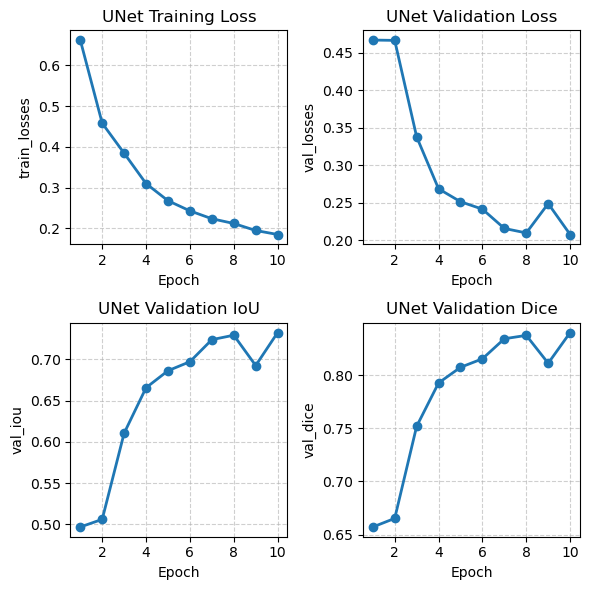

In [37]:
fig = plot_training_metrics(unet_metrics)
plt.show()


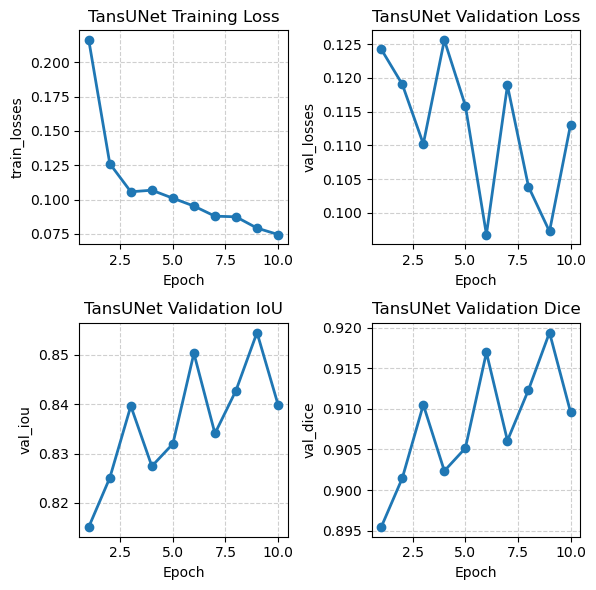

In [38]:
fig = plot_training_metrics(trans_unet_metrics, method_name="TansUNet")
plt.show()

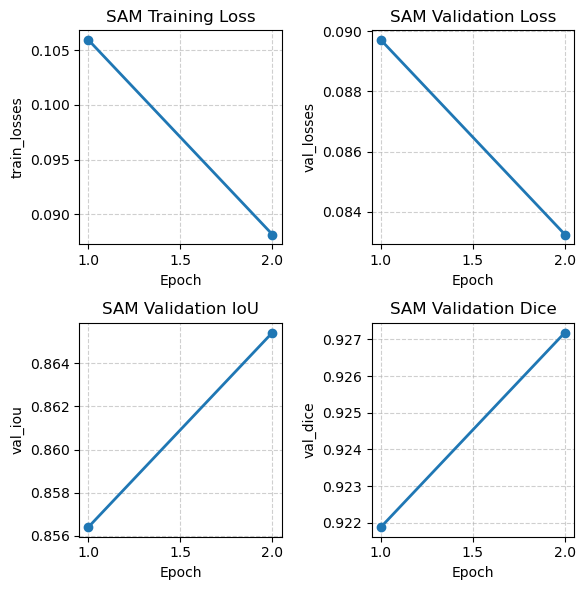

In [39]:
fig = plot_training_metrics(sam_metrics, method_name="SAM")
plt.show()

## Test Results

In [48]:
unet_test_loss, unet_test_iou, unet_test_dice = evaluate(unet, segmentation_loss, test_loader)

In [54]:
tans_unet_test_loss, trans_unet_test_iou, trans_unet_test_dice = evaluate(trans_unet, segmentation_loss, test_loader)

In [55]:
print(f"UNet test loss {unet_test_loss}, UNet test IoU {unet_test_iou}, UNet test Dice {unet_test_dice}")
print(f"TransUNet test loss {tans_unet_test_loss}, TransUNet test IoU {trans_unet_test_iou}, TransUNet test Dice {trans_unet_test_dice}")

UNet test loss 0.20690185177046044, UNet test IoU 0.7342977745737627, UNet test Dice 0.8401073985755931
TransUNet test loss 0.1256768291638479, TransUNet test IoU 0.8357814444589355, TransUNet test Dice 0.9068999590600869


## Visualization

In [65]:
def visualize_prediction(model, image, mask=None, threshold=0.5):
    model.eval()
    model.to(device)
    if image.dim() == 3:
        image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():
        pred = model(image) 
        pred = F.interpolate(
            pred,
            size=image.shape[-2:],
            mode='bilinear',
            align_corners=False
        )
        pred = torch.sigmoid(pred)
        pred_mask = (pred > threshold).float().squeeze().cpu().numpy()

    img_np = image.squeeze(0).cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    img_np = (img_np * 255).astype(np.uint8)
    
    if mask is not None:
        gt_mask = mask.squeeze().cpu().numpy()
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(img_np)
        axes[0].set_title('Input Image')
        axes[0].axis('off')

        axes[1].imshow(gt_mask, cmap='gray')
        axes[1].set_title('Ground Truth Mask')
        axes[1].axis('off')

        axes[2].imshow(pred_mask, cmap='gray')
        axes[2].set_title('Predicted Mask')
        axes[2].axis('off')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_np)
        axes[0].set_title('Input Image')
        axes[0].axis('off')

        axes[1].imshow(pred_mask, cmap='gray')
        axes[1].set_title('Predicted Mask')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()


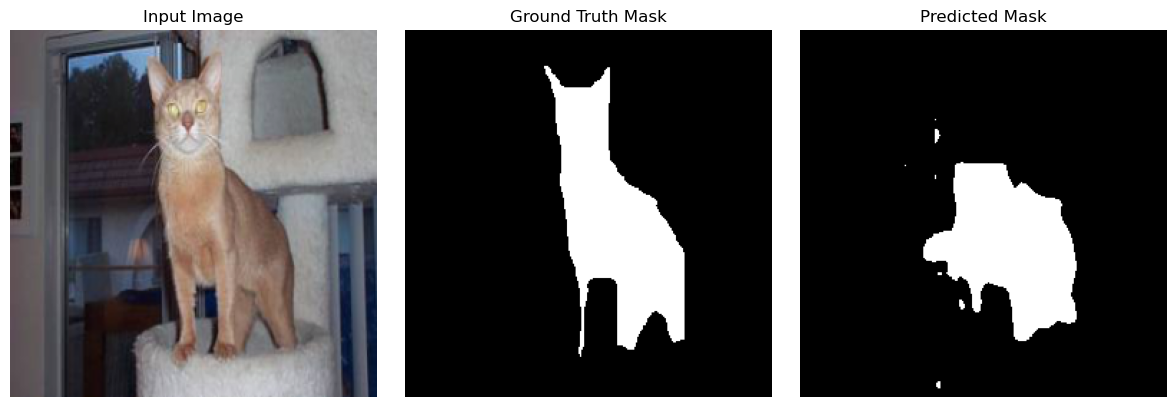

In [72]:
iterator = iter(test_loader)
images, masks = next(iterator)
visualize_prediction(
    unet,
    images[1],                     
    mask=masks[1],               
)

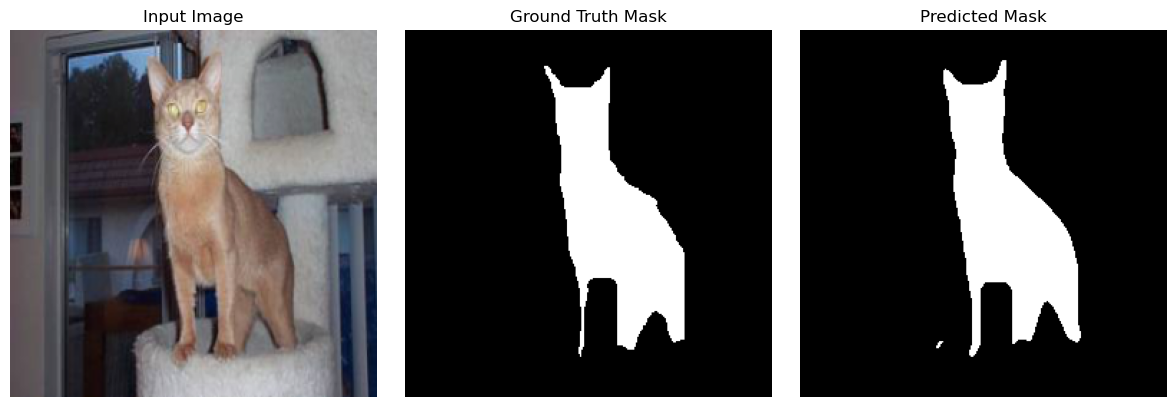

In [73]:
visualize_prediction(
    trans_unet,
    images[1],                     
    mask=masks[1],               
)

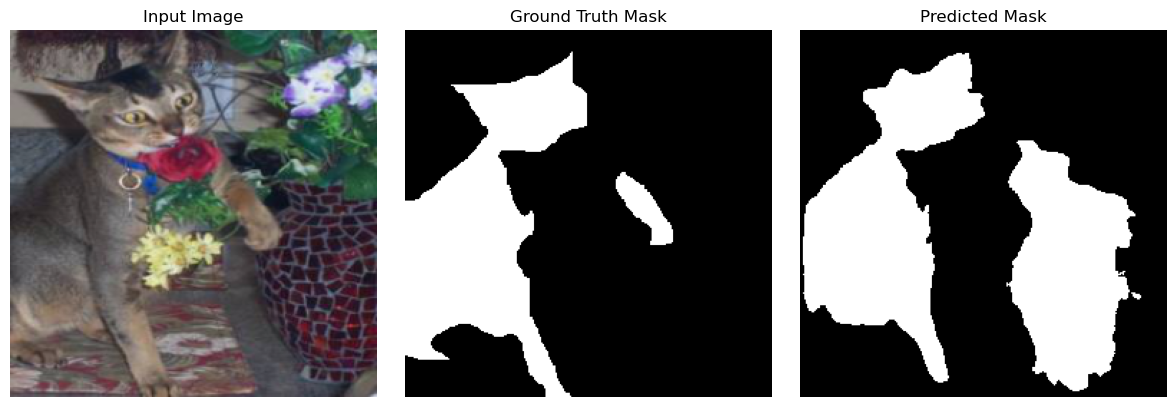

In [74]:
images, masks = next(iterator)
visualize_prediction(
    unet,
    images[1],                     
    mask=masks[1],               
)

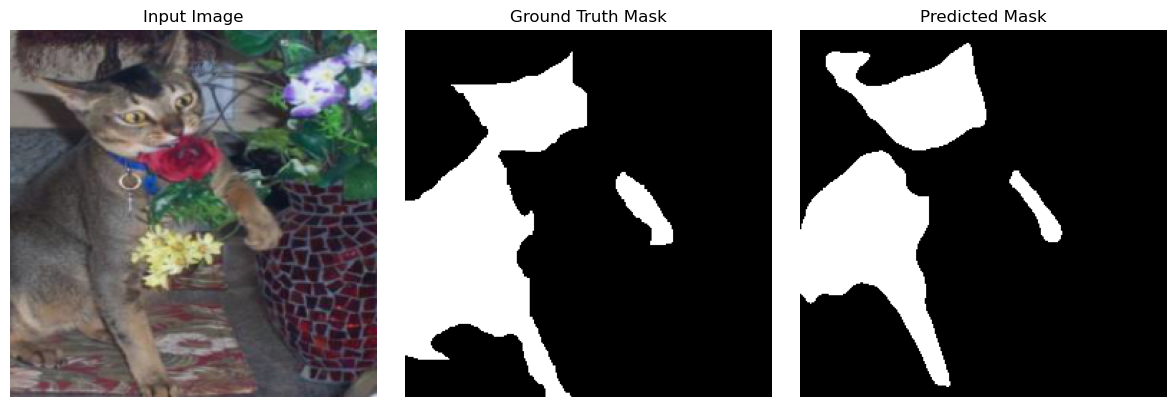

In [75]:
visualize_prediction(
    trans_unet,
    images[1],                     
    mask=masks[1],               
)

# Analysis

All the 3 models show good training and validation loss curves indicating stable learning. Other than that UNet and TransUNet show simmilar results to the validation data in the test data. This means these 2 models have learned good features from the training set. Although I was not able to run the tests for the SAM Model because of extreme limitations on the university colab GPU (I have tried dozens of times and played all the tricks in the book). Overall over the validation set SAM has ahceived the highest results followed by TransUNet.

Now comparing the masks created by these 3 methods shows that overall the masks created by UNet are alot noisier than masks created by TransUNet and SAM. In the first example the head of the cat is completely ignored because the neck has the same color and texture as the background, while TransUNet has detected the neck of the cat and created a meaningful mask.

In the second example UNet has mistakenly masked the flowerpot with the cat while TransUnet has understood that the cat and the pot are seperate from each other.

Another clear difference is the fact that the borders created by TransUNet are generally smoother than that of TransUNet. I think this and the fact that TransUNet seems to mask objects with seperated parts better is a result of the global understanding provided by the transformer in the encoder.

## Code of conduct
I have used AI generated code for :
1. Visualization functions
2. The training loops other than the loss functions (focal+bce) and loss calculation for SAM

Also the TransUNet model uses resnet50 as the encoder. The weights for this model where provided in HW2.

Because of limitations on the universities colab (limited GPU) I was not able to test the SAM model and visualize the masks, although I have done that in Q5.